In [1]:
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, f1_score,
    precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
print('✅ All libraries loaded.')

✅ All libraries loaded.


In [3]:
from google.colab import files


df = pd.read_csv("earthquake.csv")

print(f'✅ Loaded successfully')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')

✅ Loaded successfully
Shape: (741760, 23)

Columns: ['id', 'time', 'year', 'month', 'day_of_year', 'hour', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'place', 'type', 'tsunami', 'mag_category', 'depth_category', 'nst', 'gap', 'dmin', 'rms', 'net', 'updated', 'status']


In [4]:
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,id,time,year,month,day_of_year,hour,latitude,longitude,depth,mag,...,tsunami,mag_category,depth_category,nst,gap,dmin,rms,net,updated,status
0,cent19000105190000000,1900-01-05 19:00:00+00:00,1900.0,1.0,5.0,19.0,-3.00,102.00,NaN,7.0,...,0.0,Major (6-7),NaN,NaN,NaN,NaN,NaN,cent,2025-04-18T00:16:56.005Z,reviewed
1,cent19000111090700000,1900-01-11 09:07:00+00:00,1900.0,1.0,11.0,9.0,-5.00,148.00,NaN,7.0,...,0.0,Major (6-7),NaN,NaN,NaN,NaN,NaN,cent,2025-04-18T22:55:15.621Z,reviewed
2,cent19000120063300000,1900-01-20 06:33:00+00:00,1900.0,1.0,20.0,6.0,20.00,-105.00,NaN,7.3,...,0.0,Great (7-8),NaN,NaN,NaN,NaN,NaN,cent,2025-04-19T23:36:34.400Z,reviewed
3,cent19000131192200000,1900-01-31 19:22:00+00:00,1900.0,1.0,31.0,19.0,48.00,146.00,450.0,7.5,...,0.0,Great (7-8),Deep (300-700km),NaN,NaN,NaN,NaN,cent,2025-04-26T21:47:57.256Z,reviewed
4,ushis388,1900-04-09 14:00:00+00:00,1900.0,4.0,99.0,14.0,41.37,-81.85,0.0,3.4,...,0.0,Light (3-4),Shallow (0-70km),NaN,NaN,NaN,NaN,ushis,2023-12-03T23:47:09.672Z,automatic


In [5]:
print('=== Data types and memory ===')
df.info()

=== Data types and memory ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 741760 entries, 0 to 741759
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              741760 non-null  object 
 1   time            741760 non-null  object 
 2   year            741759 non-null  float64
 3   month           741759 non-null  float64
 4   day_of_year     741759 non-null  float64
 5   hour            741759 non-null  float64
 6   latitude        741759 non-null  float64
 7   longitude       741759 non-null  float64
 8   depth           740867 non-null  float64
 9   mag             741759 non-null  float64
 10  magType         741676 non-null  object 
 11  place           741759 non-null  object 
 12  type            741759 non-null  object 
 13  tsunami         741759 non-null  float64
 14  mag_category    741759 non-null  object 
 15  depth_category  740861 non-null  object 
 16  nst             408081 non

In [6]:
print('=== Summary statistics ===')
df.describe()

=== Summary statistics ===


,year,month,day_of_year,hour,latitude,longitude,depth,mag,tsunami,nst,gap,dmin,rms
count,741759.000000,741759.000000,741759.000000,741759.000000,741759.000000,741759.000000,740867.000000,741759.000000,741759.0,408081.000000,386616.000000,110368.000000,565343.000000
mean,1996.250893,6.481441,181.831793,11.580083,20.379626,-15.058371,50.978575,3.870698,0.0,32.914198,145.919973,1.219587,0.747197
std,15.125608,3.431170,104.838608,6.972317,28.902998,117.826039,94.500033,0.950106,0.0,55.904671,82.238752,3.232820,0.520884
min,1900.000000,1.000000,1.000000,0.000000,-84.422000,-179.999000,-4.000000,2.120000,0.0,0.000000,0.000000,0.000000,-1.000000
25%,1989.000000,4.000000,92.000000,5.000000,-2.800000,-118.584000,10.000000,3.000000,0.0,8.000000,80.000000,0.065087,0.360000
50%,2000.000000,6.000000,181.000000,12.000000,32.233000,-60.824000,22.000000,4.000000,0.0,16.000000,129.900000,0.296000,0.800000
75%,2007.000000,9.000000,273.000000,18.000000,40.140000,118.256000,43.000000,4.600000,0.0,35.000000,202.900000,0.955000,1.070000
max,2015.000000,12.000000,366.000000,23.000000,87.221000,180.000000,735.800000,9.500000,0.0,934.000000,360.000000,64.498000,104.330000


In [7]:
print('=== Missing values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values(
    'missing_pct', ascending=False
)
print(missing_df)

=== Missing values ===
                missing_count  missing_pct
dmin                   631392        85.12
gap                    355144        47.88
nst                    333679        44.98
rms                    176417        23.78
depth                     893         0.12
depth_category            899         0.12
magType                    84         0.01
latitude                    1         0.00
month                       1         0.00
year                        1         0.00
hour                        1         0.00
day_of_year                 1         0.00
longitude                   1         0.00
mag_category                1         0.00
tsunami                     1         0.00
type                        1         0.00
place                       1         0.00
mag                         1         0.00
net                         1         0.00
updated                     1         0.00
status                      1         0.00


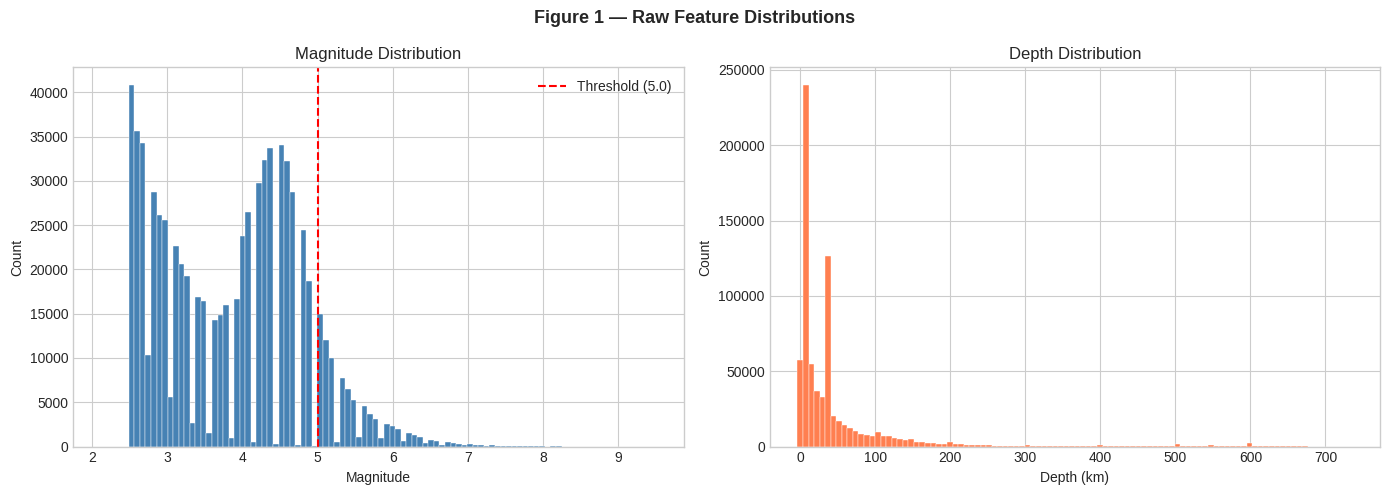

In [8]:
# Magnitude and depth distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['mag'].dropna(), bins=100, color='steelblue',
             edgecolor='white', linewidth=0.3)
axes[0].axvline(x=5.0, color='red', linestyle='--',
                linewidth=1.5, label='Threshold (5.0)')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Count')
axes[0].set_title('Magnitude Distribution')
axes[0].legend()

axes[1].hist(df['depth'].dropna(), bins=100, color='coral',
             edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Depth (km)')
axes[1].set_ylabel('Count')
axes[1].set_title('Depth Distribution')

plt.suptitle('Figure 1 — Raw Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_raw_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

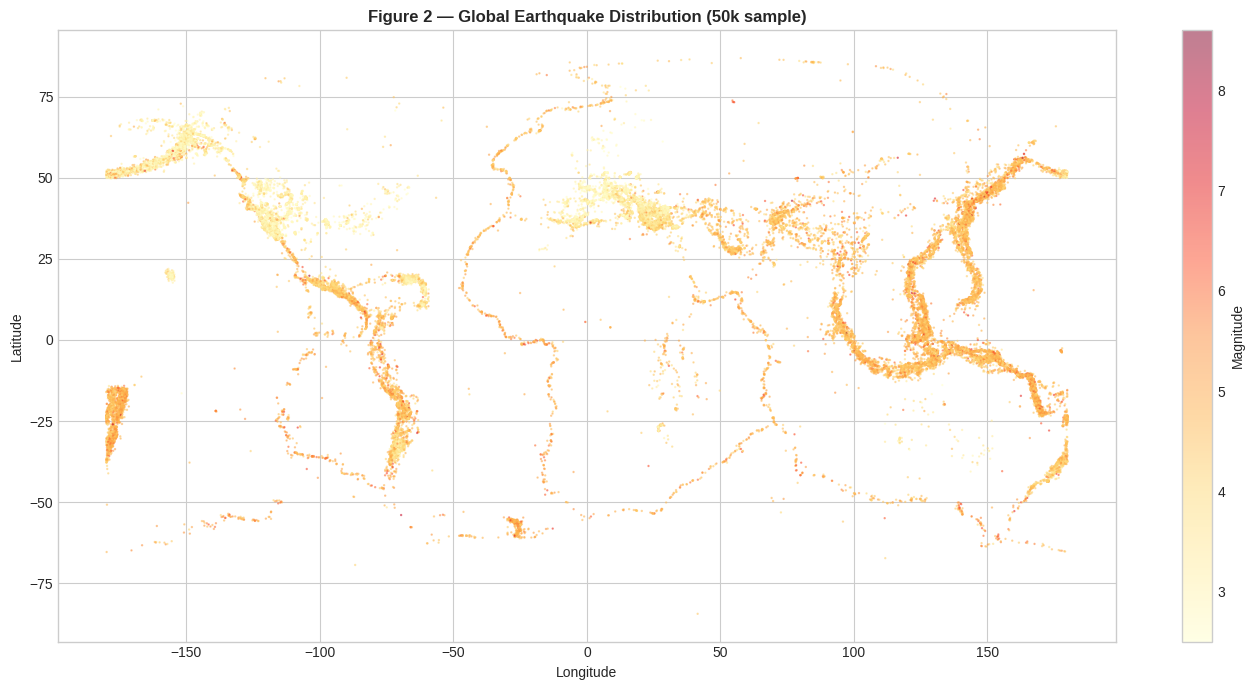

In [9]:
# Global map of earthquake locations
fig, ax = plt.subplots(figsize=(14, 7))

sample = df[['latitude', 'longitude', 'mag']].dropna().sample(
    n=min(50000, len(df)), random_state=RANDOM_STATE
)
scatter = ax.scatter(
    sample['longitude'], sample['latitude'],
    c=sample['mag'], cmap='YlOrRd', s=0.5, alpha=0.5
)
plt.colorbar(scatter, label='Magnitude')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Figure 2 — Global Earthquake Distribution (50k sample)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_global_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print(f'Starting rows: {len(df):,}')

# Step 1: Keep only earthquake events
if 'type' in df.columns:
    before = len(df)
    df = df[df['type'] == 'earthquake'].copy()
    print(f'After removing non-earthquakes:  {len(df):,}  (removed {before - len(df):,})')

# Step 2: Drop rows missing core features
before = len(df)
df = df.dropna(subset=['mag', 'depth', 'latitude', 'longitude'])
print(f'After dropping missing core cols: {len(df):,}  (removed {before - len(df):,})')

# Step 3: Remove physically implausible values
before = len(df)
df = df[(df['depth'] >= 0) & (df['depth'] <= 750)]
df = df[(df['mag'] >= -2)  & (df['mag'] <= 10)]
print(f'After removing implausible vals:  {len(df):,}  (removed {before - len(df):,})')

print(f'\n✅ Clean dataset: {len(df):,} rows')

Starting rows: 741,760
After removing non-earthquakes:  731,151  (removed 10,609)
After dropping missing core cols: 730,260  (removed 891)
After removing implausible vals:  720,612  (removed 9,648)

✅ Clean dataset: 720,612 rows


In [11]:
# Time features
if 'time' in df.columns:
    df['time']  = pd.to_datetime(df['time'], utc=True, errors='coerce')
    df['year']  = df['time'].dt.year
    df['month'] = df['time'].dt.month
    df['hour']  = df['time'].dt.hour
    print('✅ Time features: year, month, hour')

# Depth category (seismological standard)
df['depth_category'] = pd.cut(
    df['depth'],
    bins=[-1, 70, 300, 750],
    labels=[0, 1, 2]
).astype(int)
print('✅ depth_category: 0=shallow, 1=intermediate, 2=deep')

# Absolute latitude
df['abs_latitude'] = df['latitude'].abs()
print('✅ abs_latitude')

# Ring of Fire proxy flag
df['in_ring_of_fire'] = (
    (df['latitude'].abs() < 60) &
    ((df['longitude'] < -60) | (df['longitude'] > 100))
).astype(int)
print('✅ in_ring_of_fire')

# Encode magType
if 'magType' in df.columns:
    top_types = df['magType'].value_counts().nlargest(8).index
    df['magType_clean']   = df['magType'].where(df['magType'].isin(top_types), 'other')
    le                    = LabelEncoder()
    df['magType_encoded'] = le.fit_transform(df['magType_clean'].astype(str))
    print(f'✅ magType_encoded — classes: {list(le.classes_)}')

print('\n✅ Feature engineering complete')

✅ Time features: year, month, hour
✅ depth_category: 0=shallow, 1=intermediate, 2=deep
✅ abs_latitude
✅ in_ring_of_fire
✅ magType_encoded — classes: ['m', 'mb', 'mblg', 'mc', 'md', 'ml', 'mw', 'mwc', 'other']

✅ Feature engineering complete


Class distribution (threshold = mag >= 5.0):
  Not significant (0):    634,809  (88.1%)
  Significant     (1):     85,803  (11.9%)

Imbalance ratio: 7.4:1


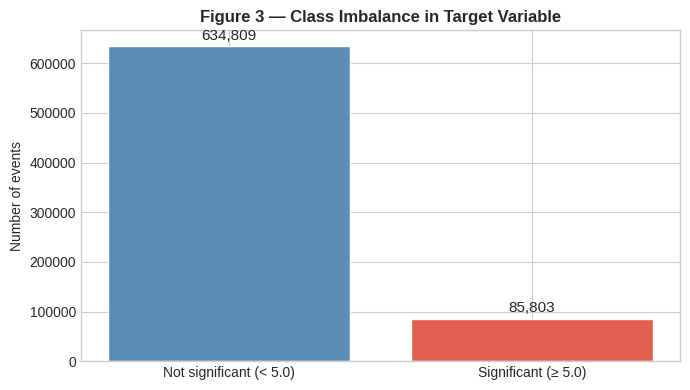

In [12]:
THRESHOLD = 5.0
df['significant'] = (df['mag'] >= THRESHOLD).astype(int)

counts = df['significant'].value_counts()
pct    = df['significant'].value_counts(normalize=True) * 100

print(f'Class distribution (threshold = mag >= {THRESHOLD}):')
print(f'  Not significant (0): {counts[0]:>10,}  ({pct[0]:.1f}%)')
print(f'  Significant     (1): {counts[1]:>10,}  ({pct[1]:.1f}%)')
print(f'\nImbalance ratio: {counts[0]/counts[1]:.1f}:1')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#5b8db8', '#e05f4e']
bars   = ax.bar(
    ['Not significant (< 5.0)', 'Significant (≥ 5.0)'],
    [counts[0], counts[1]],
    color=colors, edgecolor='white'
)
for bar, count in zip(bars, [counts[0], counts[1]]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.01,
        f'{count:,}', ha='center', va='bottom', fontsize=11
    )
ax.set_ylabel('Number of events')
ax.set_title('Figure 3 — Class Imbalance in Target Variable', fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Core features always present
FEATURE_COLS = [
    'depth', 'latitude', 'longitude',
    'abs_latitude', 'depth_category', 'in_ring_of_fire'
]

# Add optional columns only if they exist
for col in ['nst', 'gap', 'dmin', 'rms', 'horizontalError',
            'depthError', 'magNst', 'year', 'month', 'hour', 'magType_encoded']:
    if col in df.columns:
        FEATURE_COLS.append(col)

TARGET = 'significant'

model_df = df[FEATURE_COLS + [TARGET]].dropna()
print(f'Modelling dataset: {model_df.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

X = model_df[FEATURE_COLS]
y = model_df[TARGET]

# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'\nTraining set:   {X_train.shape[0]:>9,} rows')
print(f'Validation set: {X_val.shape[0]:>9,} rows')
print(f'Test set:       {X_test.shape[0]:>9,} rows')

# Scale features
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_val_sc    = scaler.transform(X_val)
X_test_sc   = scaler.transform(X_test)

# Class weights
weights          = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

# XGBoost scale_pos_weight
neg_count        = (y_train == 0).sum()
pos_count        = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'\nClass weights:      {class_weight_dict}')
print(f'scale_pos_weight:   {scale_pos_weight:.2f}')
print('\n✅ Split and scaling complete')

Modelling dataset: (1164, 15)
Features (14): ['depth', 'latitude', 'longitude', 'abs_latitude', 'depth_category', 'in_ring_of_fire', 'nst', 'gap', 'dmin', 'rms', 'year', 'month', 'hour', 'magType_encoded']

Training set:         814 rows
Validation set:       175 rows
Test set:             175 rows

Class weights:      {0: np.float64(0.5018495684340321), 1: np.float64(135.66666666666666)}
scale_pos_weight:   270.33

✅ Split and scaling complete


=== Logistic Regression — Validation ===
                 precision    recall  f1-score   support

Not significant       0.99      0.84      0.91       174
    Significant       0.00      0.00      0.00         1

       accuracy                           0.84       175
      macro avg       0.50      0.42      0.46       175
   weighted avg       0.99      0.84      0.91       175

ROC-AUC: 0.0057


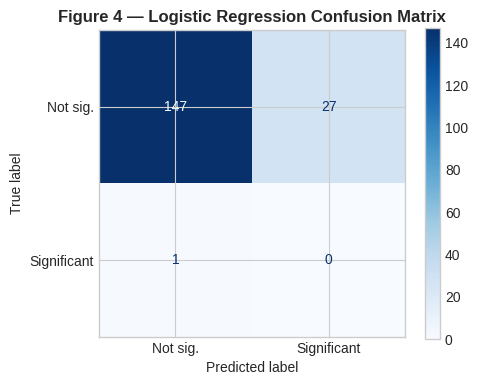

In [14]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr.fit(X_train_sc, y_train)

lr_val_preds = lr.predict(X_val_sc)
lr_val_proba = lr.predict_proba(X_val_sc)[:, 1]
lr_f1        = f1_score(y_val, lr_val_preds)
lr_roc       = roc_auc_score(y_val, lr_val_proba)
lr_recall    = recall_score(y_val, lr_val_preds)
lr_precision = precision_score(y_val, lr_val_preds)

print('=== Logistic Regression — Validation ===')
print(classification_report(y_val, lr_val_preds,
      target_names=['Not significant', 'Significant']))
print(f'ROC-AUC: {lr_roc:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_val_preds,
    display_labels=['Not sig.', 'Significant'],
    cmap='Blues', ax=ax
)
ax.set_title('Figure 4 — Logistic Regression Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_lr_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

=== Random Forest — Validation ===
                 precision    recall  f1-score   support

Not significant       0.99      1.00      1.00       174
    Significant       0.00      0.00      0.00         1

       accuracy                           0.99       175
      macro avg       0.50      0.50      0.50       175
   weighted avg       0.99      0.99      0.99       175

ROC-AUC: 0.5948


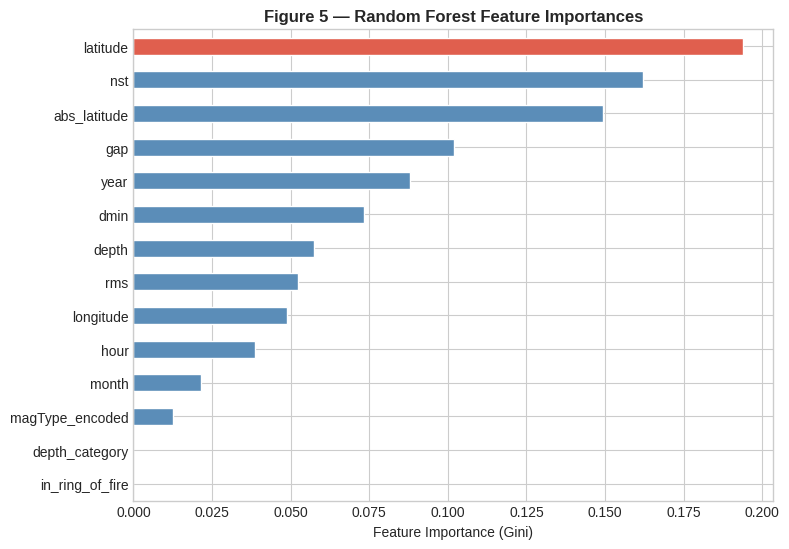

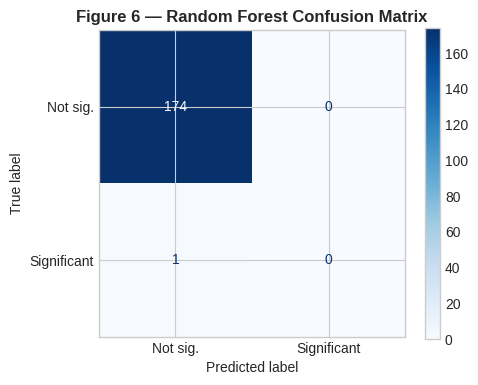

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_val_preds = rf.predict(X_val)
rf_val_proba = rf.predict_proba(X_val)[:, 1]
rf_f1        = f1_score(y_val, rf_val_preds)
rf_roc       = roc_auc_score(y_val, rf_val_proba)
rf_recall    = recall_score(y_val, rf_val_preds)
rf_precision = precision_score(y_val, rf_val_preds)

print('=== Random Forest — Validation ===')
print(classification_report(y_val, rf_val_preds,
      target_names=['Not significant', 'Significant']))
print(f'ROC-AUC: {rf_roc:.4f}')

# Feature importance
importances = pd.Series(
    rf.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(FEATURE_COLS) * 0.4)))
colors = ['#e05f4e' if v == importances.max() else '#5b8db8'
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Figure 5 — Random Forest Feature Importances', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, rf_val_preds,
    display_labels=['Not sig.', 'Significant'],
    cmap='Blues', ax=ax
)
ax.set_title('Figure 6 — Random Forest Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_rf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

=== XGBoost — Validation ===
                 precision    recall  f1-score   support

Not significant       0.99      1.00      1.00       174
    Significant       0.00      0.00      0.00         1

       accuracy                           0.99       175
      macro avg       0.50      0.50      0.50       175
   weighted avg       0.99      0.99      0.99       175

ROC-AUC: 0.7184


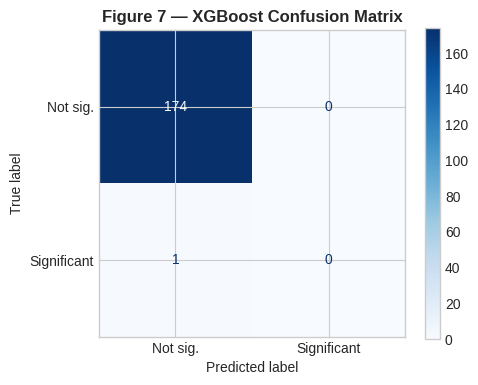

In [16]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_val_preds = xgb.predict(X_val)
xgb_val_proba = xgb.predict_proba(X_val)[:, 1]
xgb_f1        = f1_score(y_val, xgb_val_preds)
xgb_roc       = roc_auc_score(y_val, xgb_val_proba)
xgb_recall    = recall_score(y_val, xgb_val_preds)
xgb_precision = precision_score(y_val, xgb_val_preds)

print('=== XGBoost — Validation ===')
print(classification_report(y_val, xgb_val_preds,
      target_names=['Not significant', 'Significant']))
print(f'ROC-AUC: {xgb_roc:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, xgb_val_preds,
    display_labels=['Not sig.', 'Significant'],
    cmap='Blues', ax=ax
)
ax.set_title('Figure 7 — XGBoost Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_xgb_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

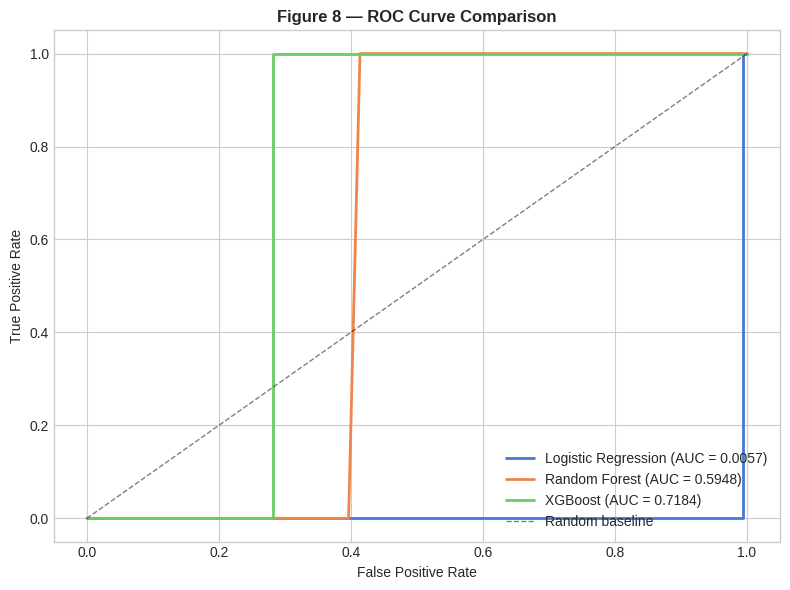

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('Logistic Regression', lr_val_proba,  '#4878d0'),
    ('Random Forest',       rf_val_proba,  '#ee854a'),
    ('XGBoost',             xgb_val_proba, '#6acc65'),
]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})',
            linewidth=2, color=color)

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 8 — ROC Curve Comparison', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig8_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Running 5-fold cross-validation...

Logistic Regression        ROC-AUC: nan ± nan
Random Forest              ROC-AUC: nan ± nan
XGBoost                    ROC-AUC: nan ± nan


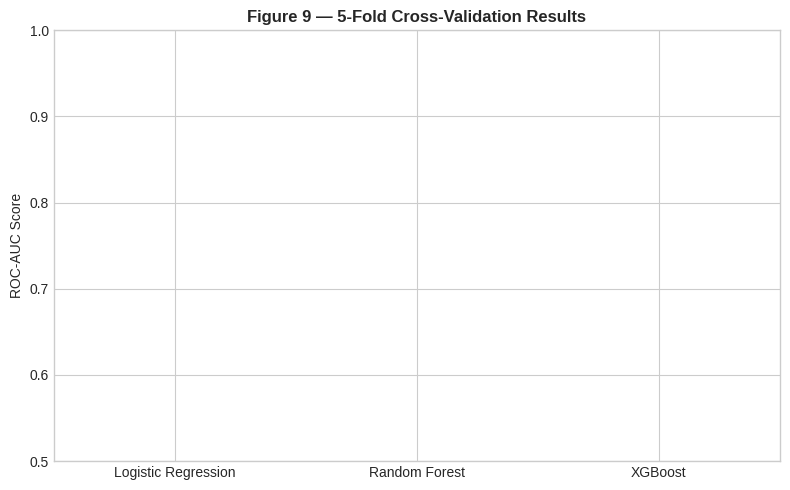

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_size = min(100_000, len(X_train))
idx     = np.random.RandomState(RANDOM_STATE).choice(len(X_train), cv_size, replace=False)
X_cv    = X_train.iloc[idx]
y_cv    = y_train.iloc[idx]
X_cv_sc = scaler.transform(X_cv)

print('Running 5-fold cross-validation...\n')
cv_results = {}

for name, model, X_input in [
    ('Logistic Regression',
     LogisticRegression(class_weight='balanced', max_iter=500, random_state=RANDOM_STATE),
     X_cv_sc),
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1),
     X_cv),
    ('XGBoost',
     XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight,
                   random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
     X_cv),
]:
    scores = cross_val_score(model, X_input, y_cv,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [cv_results[k] for k in cv_results],
    labels=list(cv_results.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='#5b8db8', color='#2c5f8a'),
    medianprops=dict(color='#e05f4e', linewidth=2)
)
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim(0.5, 1.0)
ax.set_title('Figure 9 — 5-Fold Cross-Validation Results', fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
summary = pd.DataFrame({
    'Model':             ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Val F1':            [round(lr_f1, 4),        round(rf_f1, 4),        round(xgb_f1, 4)],
    'Val Precision':     [round(lr_precision, 4), round(rf_precision, 4), round(xgb_precision, 4)],
    'Val Recall':        [round(lr_recall, 4),    round(rf_recall, 4),    round(xgb_recall, 4)],
    'Val ROC-AUC':       [round(lr_roc, 4),       round(rf_roc, 4),       round(xgb_roc, 4)],
    'CV ROC-AUC (mean)': [round(cv_results['Logistic Regression'].mean(), 4),
                          round(cv_results['Random Forest'].mean(), 4),
                          round(cv_results['XGBoost'].mean(), 4)],
    'CV ROC-AUC (std)':  [round(cv_results['Logistic Regression'].std(), 4),
                          round(cv_results['Random Forest'].std(), 4),
                          round(cv_results['XGBoost'].std(), 4)],
})
print('Table 1 — Model Comparison Summary')
summary

Table 1 — Model Comparison Summary


,Model,Val F1,Val Precision,Val Recall,Val ROC-AUC,CV ROC-AUC (mean),CV ROC-AUC (std)
0,Logistic Regression,0.0,0.0,0.0,0.0057,NaN,NaN
1,Random Forest,0.0,0.0,0.0,0.5948,NaN,NaN
2,XGBoost,0.0,0.0,0.0,0.7184,NaN,NaN


=== XGBoost — FINAL TEST SET ===
                 precision    recall  f1-score   support

Not significant       0.99      0.99      0.99       174
    Significant       0.00      0.00      0.00         1

       accuracy                           0.99       175
      macro avg       0.50      0.50      0.50       175
   weighted avg       0.99      0.99      0.99       175

ROC-AUC: 0.1264


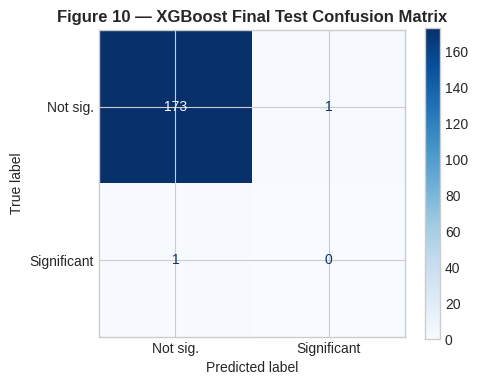

In [20]:
FINAL_MODEL      = xgb
FINAL_MODEL_NAME = 'XGBoost'

test_preds = FINAL_MODEL.predict(X_test)
test_proba = FINAL_MODEL.predict_proba(X_test)[:, 1]

print(f'=== {FINAL_MODEL_NAME} — FINAL TEST SET ===')
print(classification_report(y_test, test_preds,
      target_names=['Not significant', 'Significant']))
print(f'ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_preds,
    display_labels=['Not sig.', 'Significant'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Figure 10 — {FINAL_MODEL_NAME} Final Test Confusion Matrix',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_final_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import joblib
from google.colab import files

joblib.dump(xgb,          'final_model.pkl')
joblib.dump(scaler,       'scaler.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')

print('✅ Saved: final_model.pkl')
print('✅ Saved: scaler.pkl')
print('✅ Saved: feature_cols.pkl')

files.download('final_model.pkl')
files.download('scaler.pkl')
files.download('feature_cols.pkl')

✅ Saved: final_model.pkl
✅ Saved: scaler.pkl
✅ Saved: feature_cols.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>